In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--lookback_nsample', '64',
        '--forecast_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '32',
        '--seg_nsample_trans', '16',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 626, 4])


NameError: name 'tata' is not defined

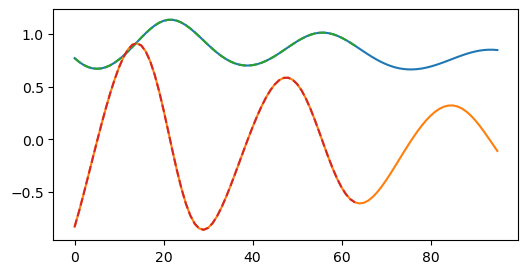

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.lookback_nsample + args.forecast_nsample]
        back = replay[:, offset:offset + args.lookback_nsample]

        true, _ = dataset.normalizer.normalize(true)
        back, _ = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        #plt.plot(true_n[jdata, :, :2])
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.100907, valid=1.207356, test=1.153049
	validation loss decreased (inf -> 1.207356), saving model ...
	epoch 2 losses: train=1.068205, valid=1.192150, test=1.126180
	validation loss decreased (1.207356 -> 1.192150), saving model ...
	epoch 3 losses: train=1.047370, valid=1.179520, test=1.110179
	validation loss decreased (1.192150 -> 1.179520), saving model ...
	epoch 4 losses: train=1.032278, valid=1.169737, test=1.097426
	validation loss decreased (1.179520 -> 1.169737), saving model ...
	epoch 5 losses: train=1.020667, valid=1.158742, test=1.083280
	validation loss decreased (1.169737 -> 1.158742), saving model ...
	epoch 6 losses: train=1.007793, valid=1.146248, test=1.067618
	validation loss decreased (1.158742 -> 1.146248), saving model ...
	epoch 7 losses: train=0.993383, valid=1.133255, test=1.051038
	validation loss decreased (1.146248 -> 1.133255), saving model ...
	epoch 8 losses: train=0.977930, valid=1.119170, test=1.03

In [12]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

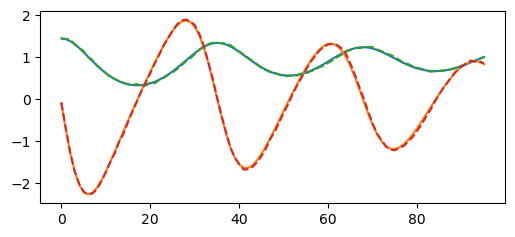

NameError: name 'tata' is not defined

In [23]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

print(tata.shape)

In [24]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.949523, valid=0.943672, test=0.290280
	validation loss decreased (inf -> 0.943672), saving model ...
	epoch 2 losses: train=0.925316, valid=0.933069, test=0.286718
	validation loss decreased (0.943672 -> 0.933069), saving model ...
	epoch 3 losses: train=0.915400, valid=0.922879, test=0.282435
	validation loss decreased (0.933069 -> 0.922879), saving model ...
	epoch 4 losses: train=0.906775, valid=0.914207, test=0.278673
	validation loss decreased (0.922879 -> 0.914207), saving model ...
	epoch 5 losses: train=0.899126, valid=0.905966, test=0.275409
	validation loss decreased (0.914207 -> 0.905966), saving model ...
	epoch 6 losses: train=0.891776, valid=0.897319, test=0.272242
	validation loss decreased (0.905966 -> 0.897319), saving model ...
	epoch 7 losses: train=0.883970, valid=0.888087, test=0.269116
	validation loss decreased (0.897319 -> 0.888087), saving model ...
	epoch 8 losses: train=0.875656, valid=0.878093, te

In [25]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

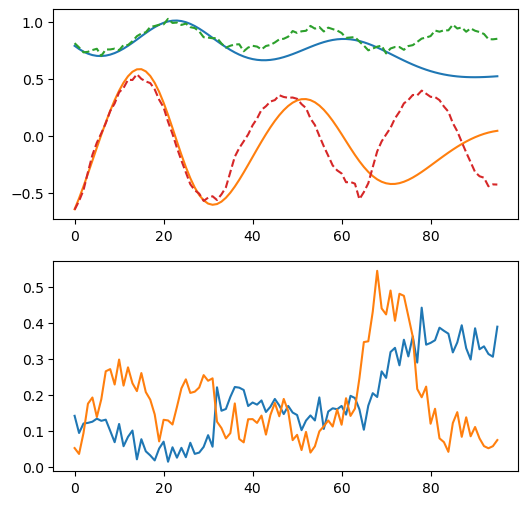

In [27]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [28]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=1.010401, valid=1.031940, test=0.852472
	validation loss decreased (inf -> 1.031940), saving model ...
	epoch 2 losses: train=0.937861, valid=1.030707, test=0.819896
	validation loss decreased (1.031940 -> 1.030707), saving model ...
	epoch 3 losses: train=0.969222, valid=1.060554, test=0.792277
	early stopping counter: 1 out of 100
	epoch 4 losses: train=0.891061, valid=1.010532, test=0.715581
	validation loss decreased (1.030707 -> 1.010532), saving model ...
	epoch 5 losses: train=0.829546, valid=0.901798, test=0.616748
	validation loss decreased (1.010532 -> 0.901798), saving model ...
	epoch 6 losses: train=0.674343, valid=0.829730, test=0.552154
	validation loss decreased (0.901798 -> 0.829730), saving model ...
	epoch 7 losses: train=0.610694, valid=0.793506, test=0.528256
	validation loss decreased (0.829730 -> 0.793506), saving model ...
	epoch 8 losses: train=0.590370, valid=0.751008, test=0.485826
	validation loss decrea

In [29]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

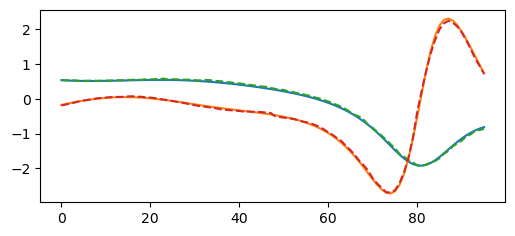

In [40]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [41]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.090547, valid=0.055530, test=0.070456
	validation loss decreased (inf -> 0.055530), saving model ...
	epoch 2 losses: train=0.058090, valid=0.050630, test=0.065252
	validation loss decreased (0.055530 -> 0.050630), saving model ...
	epoch 3 losses: train=0.054185, valid=0.047335, test=0.063009
	validation loss decreased (0.050630 -> 0.047335), saving model ...
	epoch 4 losses: train=0.049821, valid=0.045047, test=0.060725
	validation loss decreased (0.047335 -> 0.045047), saving model ...
	epoch 5 losses: train=0.045721, valid=0.043750, test=0.059008
	validation loss decreased (0.045047 -> 0.043750), saving model ...
	epoch 6 losses: train=0.044645, valid=0.042791, test=0.057787
	validation loss decreased (0.043750 -> 0.042791), saving model ...
	epoch 7 losses: train=0.043157, valid=0.041994, test=0.056929
	validation loss decreased (0.042791 -> 0.041994), saving model ...
	epoch 8 losses: train=0.042743, valid=0.041338, 

In [42]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

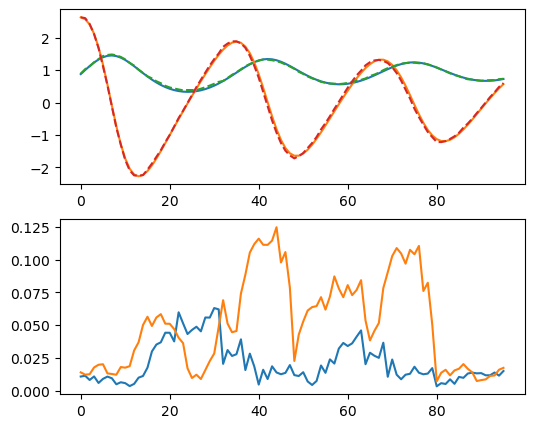

In [46]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

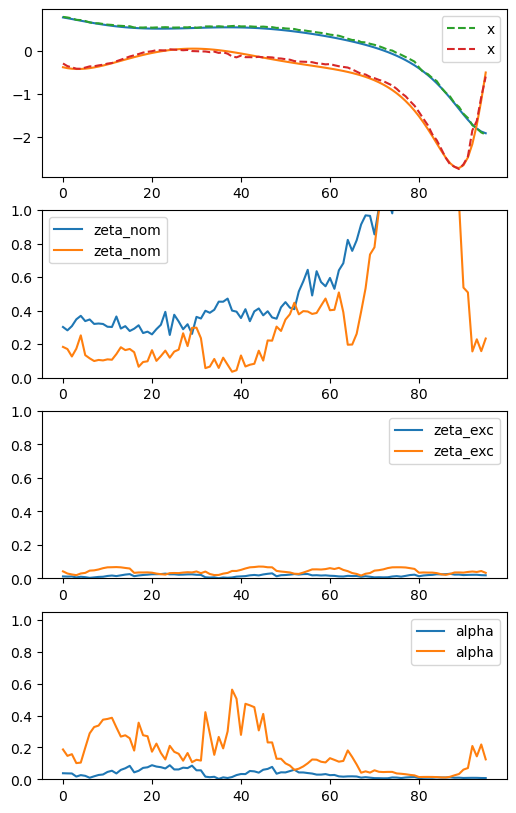

In [50]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break